This dataset analysis will be used to visualize and test the hugging face dataset. 

Goal: Pick top 10 stocks with the most articles and with the same number of distrubtions across monthly and yearly article numbers. 

In [1]:
from datasets import load_dataset

import sys
!{sys.executable} -m pip install -U matplotlib ipykernel
import matplotlib.pyplot as plt
import matplotlib
print(matplotlib.__version__)


3.10.8


Figure out top 15 stocks to generate articles based off of 

In [4]:
from datasets import load_dataset
from collections import Counter
import pandas as pd
import re
import matplotlib.pyplot as plt

# Load (streaming so we don't download everything)
ds = load_dataset(
    "Brianferrell787/financial-news-multisource",
    split="train",
    streaming=True,
    token=True  # uses your HF CLI login
)

# Pick your range (edit these)
START = pd.Timestamp("2019-01-01", tz="UTC")
END   = pd.Timestamp("2024-12-01", tz="UTC")


README.md:   0%|          | 0.00/60.6k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/131 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/131 [00:00<?, ?it/s]

I have verified that the hugging face dataset now works 

In [14]:
from collections import Counter
import json
import re
import pandas as pd
import matplotlib.pyplot as plt

def parse_extras(extra_fields_str: str) -> dict:
    if not extra_fields_str:
        return {}
    try:
        return json.loads(extra_fields_str)
    except Exception:
        return {}

def pick_stocks(extras: dict):
    stocks = extras.get("stocks")
    if isinstance(stocks, list) and stocks:
        return [str(s).strip() for s in stocks if str(s).strip()]
    return []

def is_reasonable_ticker(s: str) -> bool:
    if not s or not isinstance(s, str):
        return False
    if s.startswith("$"):  # drop indices like $SPX, $INDU
        return False
    return bool(re.fullmatch(r"[A-Z][A-Z0-9\.\-]{0,9}", s))

In [15]:
START_DATE = "2010-01-01"
END_DATE   = "2024-12-01"

PER_TICKER_CAP = 10_000          # you said “10k per stock at most”
TARGET_TICKERS = 300             # how many tickers you want to fill (tune)
MIN_TICKER_COUNT_FOR_TOP = 100   # optional: ignore ultra-rare tickers

stock_counts = Counter()
seen_in_range = 0
rows_with_stocks = 0

# For early stopping bookkeeping:
filled = set()  # tickers that have reached cap

for i, row in enumerate(ds):
    # super fast date filter: ISO date is sortable as string
    date_str = row["date"][:10]  # "YYYY-MM-DD"
    if date_str < START_DATE or date_str > END_DATE:
        continue

    seen_in_range += 1

    extras = parse_extras(row.get("extra_fields"))
    stocks = pick_stocks(extras)
    if stocks:
        rows_with_stocks += 1

    # count at most once per article per ticker
    valid = [s for s in set(stocks) if is_reasonable_ticker(s)]
    if not valid:
        continue

    for t in valid:
        if t in filled:
            continue
        stock_counts[t] += 1
        if stock_counts[t] >= PER_TICKER_CAP:
            filled.add(t)

    # Early stop condition:
    # stop once you've filled enough tickers to the cap
    if len(filled) >= TARGET_TICKERS:
        print(f"Early stop: filled {len(filled)} tickers to cap={PER_TICKER_CAP}")
        break

    # progress print every 200k scanned rows
    if i % 200_000 == 0 and i > 0:
        print(
            f"scanned={i:,} in_range={seen_in_range:,} rows_with_stocks={rows_with_stocks:,} "
            f"unique_tickers={len(stock_counts):,} filled={len(filled):,}"
        )

scanned=2,400,000 in_range=2,393,969 rows_with_stocks=155,441 unique_tickers=4,093 filled=0
scanned=2,600,000 in_range=2,593,969 rows_with_stocks=355,441 unique_tickers=4,874 filled=0
scanned=2,800,000 in_range=2,793,969 rows_with_stocks=555,441 unique_tickers=5,667 filled=0
scanned=3,000,000 in_range=2,993,969 rows_with_stocks=755,441 unique_tickers=5,855 filled=0
scanned=3,200,000 in_range=3,193,969 rows_with_stocks=955,441 unique_tickers=5,987 filled=0
scanned=3,400,000 in_range=3,393,969 rows_with_stocks=1,155,441 unique_tickers=6,150 filled=0
scanned=3,600,000 in_range=3,593,969 rows_with_stocks=1,355,441 unique_tickers=6,386 filled=0
scanned=3,800,000 in_range=3,793,969 rows_with_stocks=1,555,441 unique_tickers=6,589 filled=0
scanned=12,200,000 in_range=9,991,564 rows_with_stocks=1,632,639 unique_tickers=6,602 filled=0
scanned=12,400,000 in_range=10,189,838 rows_with_stocks=1,830,913 unique_tickers=6,604 filled=0
scanned=12,600,000 in_range=10,388,120 rows_with_stocks=2,029,195 u

In [16]:
top15 = stock_counts.most_common(15)
df_top15 = pd.DataFrame(top15, columns=["ticker", "article_count"])
df_top15

,ticker,article_count
0,KSS,10000
1,ALK,10000
2,NVS,10000
3,AXP,10000
4,FCX,10000
5,CSX,10000
6,DAL,10000
7,NTAP,10000
8,GPS,10000
9,AEO,10000


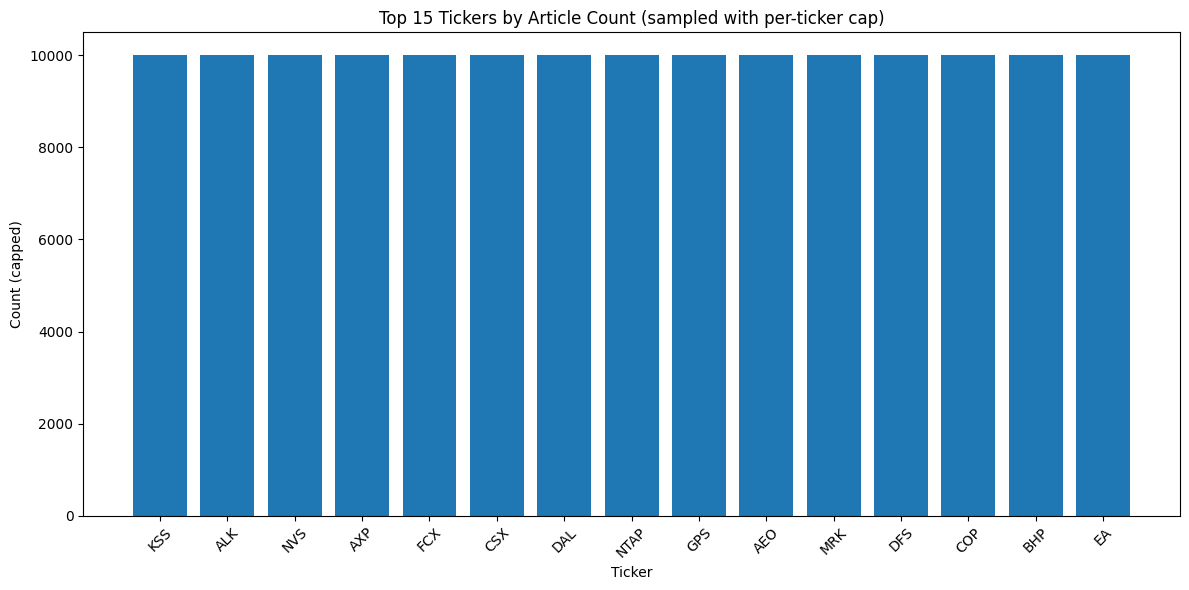

In [17]:
plt.figure(figsize=(12,6))
plt.bar(df_top15["ticker"], df_top15["article_count"])
plt.title("Top 15 Tickers by Article Count (sampled with per-ticker cap)")
plt.xlabel("Ticker")
plt.ylabel("Count (capped)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()